# LDA Inspection — Reddit Tech Stocks NLP

Inspects LDA outputs: coherence scores, topic words, topic diversity, theta distributions, and multi-K comparison.

In [6]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_context('poster')
%matplotlib inline

BASE_DIR = Path('.').resolve().parent
LDA_DIR  = BASE_DIR / 'data/topic_modeling'
print(f'LDA dir: {LDA_DIR}')

LDA dir: C:\Users\marco\Desktop\Reddit-tech-stocks-NLP\data\nlp\lda


## 1. Coherence Scores

Plot delle tre metriche al variare di K.

In [7]:
scores = pd.read_csv(LDA_DIR / 'coherence_scores.csv')
print(scores.to_string(index=False))

 K  coherence_umass  coherence_cv  coherence_npmi  topic_diversity
 5          -2.8093        0.2853         -0.0710           0.8000
 7          -1.5420        0.2777         -0.0315           0.6857
 9          -1.1498        0.2870         -0.0247           0.5222
11          -1.3307        0.2809         -0.0358           0.5909
13          -1.9366        0.2980         -0.0372           0.5000
15          -1.9793        0.2925         -0.0382           0.4133
17          -1.7943        0.2805         -0.0507           0.5000
19          -1.7160        0.2960         -0.0435           0.4263
21          -1.5579        0.2985         -0.0333           0.4238
23          -1.6868        0.2824         -0.0419           0.3783
25          -1.5166        0.2892         -0.0331           0.3960


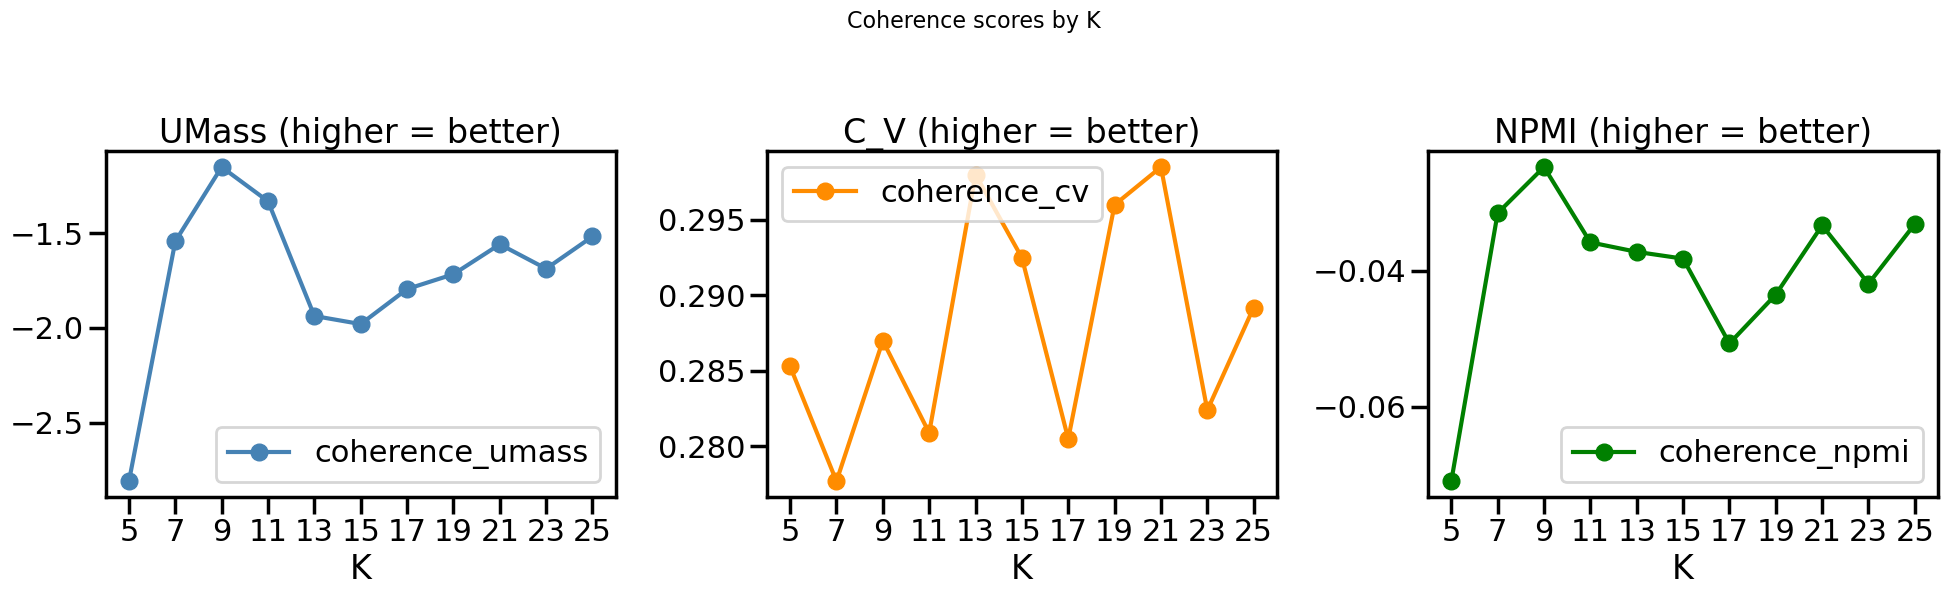

Best K by C_V  : 21
Best K by UMass: 9
Best K by NPMI : 9


In [8]:
fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(20, 6))

scores.plot.line(x='K', y='coherence_umass', ax=ax[0], marker='o', color='steelblue')
ax[0].set_title('UMass (higher = better)')
ax[0].set_xticks(scores['K'])

scores.plot.line(x='K', y='coherence_cv', ax=ax[1], marker='o', color='darkorange')
ax[1].set_title('C_V (higher = better)')
ax[1].set_xticks(scores['K'])

scores.plot.line(x='K', y='coherence_npmi', ax=ax[2], marker='o', color='green')
ax[2].set_title('NPMI (higher = better)')
ax[2].set_xticks(scores['K'])

fig.suptitle('Coherence scores by K', fontsize=16, y=1.02)
plt.tight_layout()
plt.savefig(LDA_DIR / 'coherence_plot.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Best K by C_V  : {scores.loc[scores.coherence_cv.idxmax(), 'K']}")
print(f"Best K by UMass: {scores.loc[scores.coherence_umass.idxmax(), 'K']}")
print(f"Best K by NPMI : {scores.loc[scores.coherence_npmi.idxmax(), 'K']}")

## 2. Topic Words

Top-10 e top-20 parole per topic (K scelto in `config_lda.py`).

In [9]:
tw = pd.read_csv(LDA_DIR / 'topic_words_v1.csv')

print(f"{'Topic':<8} Top-10 words")
print('-' * 80)
for tid in sorted(tw['topic_id'].unique()):
    words = tw[tw['topic_id'] == tid].head(10)['word'].tolist()
    print(f'Topic {tid:2d}: {", ".join(words)}')

Topic    Top-10 words
--------------------------------------------------------------------------------
Topic  0: red, yesterday, break, tell, bear, bull, gain, meta, morning, save
Topic  1: trade, tariff, option, tesla, well, invest, probably, gain, actually, low
Topic  2: well, tariff, option, position, point, apple, tesla, tech, growth, work
Topic  3: option, trade, profit, lot, gain, invest, win, position, point, low
Topic  4: model, deepseek, use, cost, work, hardware, cheap, build, lot, meta
Topic  5: option, profit, trade, gain, invest, value, bet, lot, low, work
Topic  6: openai, deal, revenue, invest, value, investment, trade, work, lot, well
Topic  7: trade, option, well, position, work, actually, bet, win, point, profit
Topic  8: trade, tsmc, quantum, work, business, openai, lot, take, invest, king


## 3. Topic Diversity

Fraction of unique words across all topic top-N lists. Higher = more distinct topics.

In [5]:
NUM_WORDS = 10

topic_words_list = [
    tw[tw['topic_id'] == tid].head(NUM_WORDS)['word'].tolist()
    for tid in sorted(tw['topic_id'].unique())
]

all_words    = [w for topic in topic_words_list for w in topic]
unique_words = set(all_words)
diversity    = len(unique_words) / len(all_words)

print(f'Topic Diversity (top-{NUM_WORDS}): {diversity:.4f}')
print(f'Unique words: {len(unique_words)} / {len(all_words)} total')

Topic Diversity (top-10): 0.6111
Unique words: 55 / 90 total


## 4. Distribuzione theta sui chunk sentiment

Anteprima di `results_v1.csv` — le distribuzioni topic per stock e per giorno.

In [6]:
results = pd.read_csv(LDA_DIR / 'results_v1.csv')
print(f'Shape: {results.shape}')
print(f'\nStock distribution:\n{results.stock.value_counts()}')
results.head(6)

Shape: (5971, 14)

Stock distribution:
stock
NVDA    3966
AMD     1003
PLTR    1002
Name: count, dtype: int64


,chunk_id,stock,date_start,date_end,n_messages,topic_0,topic_1,topic_2,topic_3,topic_4,topic_5,topic_6,topic_7,topic_8
0,0,AMD,2025-01-01,2025-01-01,30,0.928850,0.014991,0.011993,0.009994,0.008566,0.007495,0.006663,0.005996,0.005451
1,1,AMD,2025-01-02,2025-01-02,30,0.920725,0.016703,0.013362,0.011135,0.009544,0.008351,0.007423,0.006681,0.006074
2,2,AMD,2025-01-02,2025-01-02,30,0.910663,0.018823,0.015058,0.012549,0.010756,0.009411,0.008366,0.007529,0.006845
3,3,AMD,2025-01-02,2025-01-02,40,0.929208,0.014916,0.011932,0.009944,0.008523,0.007458,0.006629,0.005966,0.005424
4,4,AMD,2025-01-03,2025-01-03,30,0.920823,0.016682,0.013346,0.011121,0.009533,0.008341,0.007414,0.006673,0.006066
5,5,AMD,2025-01-03,2025-01-03,25,0.897385,0.021621,0.017296,0.014414,0.012354,0.010810,0.009609,0.008648,0.007862


In [7]:
# Media theta per stock
topic_cols = [c for c in results.columns if c.startswith('topic_')]
print('Mean theta per stock:')
results.groupby('stock')[topic_cols].mean().round(3)

Mean theta per stock:


,topic_0,topic_1,topic_2,topic_3,topic_4,topic_5,topic_6,topic_7,topic_8
stock,,,,,,,,,
AMD,0.910,0.019,0.015,0.013,0.011,0.010,0.008,0.008,0.007
NVDA,0.925,0.016,0.013,0.011,0.009,0.008,0.007,0.006,0.006
PLTR,0.922,0.016,0.013,0.011,0.009,0.008,0.007,0.007,0.006


## 5. Bigrams and trigrams

Loads the Gensim Phrases models from Step 1: detected phrases, top-scored bigrams/trigrams, and tokens that survived dictionary filtering.

In [ ]:
import pickle
from gensim.corpora import Dictionary

bigram_model  = pickle.load(open(LDA_DIR / 'bigram_model.pkl',  'rb'))
trigram_model = pickle.load(open(LDA_DIR / 'trigram_model.pkl', 'rb'))
dictionary    = Dictionary.load(str(LDA_DIR / 'dictionary.gensim'))

# Gensim Phrases stores scored phrases in .phrasegrams
bigram_phrases  = bigram_model.phrasegrams   # dict: (w1,w2) -> score
trigram_phrases = trigram_model.phrasegrams  # dict: (w1,w2) -> score

print(f'Bigrams detected by Phrases model:  {len(bigram_phrases):,}')
print(f'Trigrams detected by Phrases model: {len(trigram_phrases):,}')
print(f'Tokens in final dictionary:          {len(dictionary):,}')


In [ ]:
# Top-30 bigrams per score
import pandas as pd

bg_df = pd.DataFrame([
    {'phrase': '_'.join(k), 'score': v}
    for k, v in bigram_phrases.items()
]).sort_values('score', ascending=False)

print('Top-30 bigrams by score:')
print(bg_df.head(30).to_string(index=False))


In [ ]:
# Top-30 trigrams per score
tg_df = pd.DataFrame([
    {'phrase': '_'.join(k), 'score': v}
    for k, v in trigram_phrases.items()
]).sort_values('score', ascending=False)

print('Top-30 trigrams by score:')
print(tg_df.head(30).to_string(index=False))


In [ ]:
# Quanti bigrams/trigrams sono nel dizionario finale?
# A token is a bigram if it contains '_' (Gensim Phrases convention)
vocab_tokens = list(dictionary.token2id.keys())

unigrams  = [t for t in vocab_tokens if t.count('_') == 0]
bigrams_v  = [t for t in vocab_tokens if t.count('_') == 1]
trigrams_v = [t for t in vocab_tokens if t.count('_') >= 2]

print(f'Vocabolario finale: {len(vocab_tokens):,} token totali')
print(f'  Unigrams:  {len(unigrams):,}  ({len(unigrams)/len(vocab_tokens)*100:.1f}%)')
print(f'  Bigrams:   {len(bigrams_v):,}  ({len(bigrams_v)/len(vocab_tokens)*100:.1f}%)')
print(f'  Trigrams:  {len(trigrams_v):,}  ({len(trigrams_v)/len(vocab_tokens)*100:.1f}%)')
print()
print('Bigrams in vocabulary:')
print(sorted(bigrams_v)[:50])
print()
print('Trigrams in vocabulary:')
print(sorted(trigrams_v))


## 6. Word overlap across topics

Words appearing in more than one topic — signal of overlap or non-discriminative vocabulary.

In [ ]:
from collections import Counter

tw = pd.read_csv(LDA_DIR / 'topic_words_v1.csv')
TOP_N = 10  # considera solo le prime N parole per topic

word_topic_count = Counter()
for tid in tw['topic_id'].unique():
    top_words = tw[tw['topic_id'] == tid].head(TOP_N)['word'].tolist()
    for w in top_words:
        word_topic_count[w] += 1

n_topics = tw['topic_id'].nunique()
overlap = {w: c for w, c in word_topic_count.items() if c > 1}
overlap_df = pd.Series(overlap).sort_values(ascending=False)

print(f'Words in top-{TOP_N} of more than 1 topic (out of {n_topics} topics):')
print(overlap_df.to_string())
print(f'\nDiversity (top-{TOP_N}): {1 - len(overlap)/len(overlap_df) if len(overlap_df) else 1:.3f}')


## 7. Theta distributions by stock

Mean and std of theta distributions per stock. Topic_0 is the catch-all topic — its weight is retained as a feature in the downstream financial model.

In [ ]:
results = pd.read_csv(LDA_DIR / 'results_v1.csv')
topic_cols = [c for c in results.columns if c.startswith('topic_')]

print('=== Mean theta by stock ===')
print(results.groupby('stock')[topic_cols].mean().round(3).to_string())
print()
print('=== Std theta by stock ===')
print(results.groupby('stock')[topic_cols].std().round(3).to_string())
print()

# Distribuzione del topic dominante per chunk
results['dominant_topic'] = results[topic_cols].idxmax(axis=1)
print('=== Dominant topic per chunk (counts) ===')
print(results.groupby('stock')['dominant_topic'].value_counts().to_string())


In [ ]:
# Histogram of topic_0 weight by stock
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)
stocks = ['AMD', 'NVDA', 'PLTR']

for ax, stock in zip(axes, stocks):
    vals = results[results['stock'] == stock]['topic_0']
    ax.hist(vals, bins=40, color='steelblue', edgecolor='white')
    ax.axvline(vals.mean(), color='red', linestyle='--', label=f'mean={vals.mean():.2f}')
    ax.set_title(f'{stock} — topic_0')
    ax.set_xlabel('theta_0')
    ax.legend()

axes[0].set_ylabel('# chunks')
plt.suptitle('Topic_0 (catch-all) weight distribution by stock', y=1.02)
plt.tight_layout()
plt.show()


## 8. Multi-K Comparison — Topic Words Side by Side

Loads all trained models and displays their top words. Use this to verify that lower K produces more distinct topics and to document the K-selection rationale in the report.

In [ ]:
# ── Multi-K comparison ──────────────────────────────────────────────────────
from gensim.models import LdaMulticore

model_dir = LDA_DIR / 'model'
trained_ks = sorted([
    int(d.name.replace('lda_k', ''))
    for d in model_dir.iterdir()
    if d.is_dir() and d.name.startswith('lda_k')
])
print(f'Trained models found: K = {trained_ks}')

TOP_N = 10

for k in trained_ks:
    model = LdaMulticore.load(str(model_dir / f'lda_k{k}' / f'lda_k{k}'))
    print('\n' + '\u2550' * 65)
    print(f'  K = {k}')
    print('\u2550' * 65)
    for tid in range(k):
        words = [w for w, _ in model.show_topic(tid, topn=TOP_N)]
        print(f'  Topic {tid:2d}: {', '.join(words)}')


## 9. pyLDAvis — Interactive Topic Map

Generates an interactive visualisation: topic bubbles sized by prevalence, positioned by inter-topic distance (via PCA/MDS). The relevance slider λ balances global word frequency vs topic-specific salience.

Change `K_VIS` to inspect a different trained model.

In [ ]:
# ── pyLDAvis ────────────────────────────────────────────────────────────────
try:
    import pyLDAvis
    import pyLDAvis.gensim_models as gensimvis
except ImportError:
    import subprocess, sys
    subprocess.run([sys.executable, '-m', 'pip', 'install', 'pyLDAvis',
                    '--break-system-packages', '-q'])
    import pyLDAvis
    import pyLDAvis.gensim_models as gensimvis

from gensim.models import LdaMulticore
from gensim.corpora import MmCorpus, Dictionary

K_VIS = 7  # change to inspect a different trained model

model_vis  = LdaMulticore.load(str(LDA_DIR / f'model/lda_k{K_VIS}/lda_k{K_VIS}'))
corpus_bow = list(MmCorpus(str(LDA_DIR / 'corpus_bow.mm')))
dictionary = Dictionary.load(str(LDA_DIR / 'dictionary.gensim'))

pyLDAvis.enable_notebook()
vis = gensimvis.prepare(model_vis, corpus_bow, dictionary, sort_topics=False)
vis
